# RCA Troubleshooting Agent — Simple

A manageable, data-driven root cause analysis copilot.

## Engineer Flow
1. Validate machine + symptom + period (deterministic)
2. Check procedures first (expert-validated, highest trust)
3. Check Known Issues Graph (curated KB)
4. Check recent maintenance history
5. Use sensors when relevant
6. Ask user before going into deep full history
7. Ask discriminating yes/no questions when confidence is low

## Architecture
```
START → validator → agent ⇄ tool_node → extractor → agent → END
```

- **validator**: extracts machine/symptom/period, checks DB
- **agent**: ReAct loop with all tools, one system prompt
- **tool_node**: built-in ToolNode (no custom dispatcher)
- **extractor**: converts tool results into hypothesis confidence updates

In [ ]:
from typing import Any, Annotated, List
from operator import add
import uuid

from openai import OpenAI
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

from tools.tools import (
    get_current_date, calculate_date_window,
    check_machine_exists, list_available_machines,
    get_formatted_procedure_context,
    get_recent_formatted_cm_context,
    get_long_formatted_cm_context,
    get_formatted_cm_context,
    get_sensor_catalog_tool, get_threshold_events_tool,
    get_sensor_timeline_tool, get_sensor_readings_tool,
    get_remaining_life_tool,
    query_known_issues_graph,
)


BRAIN_MODEL = "gpt-4o-mini"
llm = ChatOpenAI(model=BRAIN_MODEL, temperature=0, seed=42)
print(f"LLM ready: {BRAIN_MODEL}")

LLM ready: gpt-4o-mini


In [2]:
# --- Data Models ---

class Evidence(BaseModel):
    """One traceable piece of evidence supporting or opposing a hypothesis."""
    source_type: str        # "procedure", "graph", "history", "sensor", "user", "user_neg"
    source_id: str          # filename, INT-ID, KI-ID, sensor tag — exact identifier
    section: str = ""       # section title or chunk context (for procedures)
    snippet: str = ""       # exact quote supporting this cause (≤150 chars)
    how_to_check: str = ""  # specific diagnostic step from the source
    repair_action: str = "" # specific repair/fix action from the source
    direction: str = "supports"   # "supports" or "opposes"
    weight: float = 0.0

class Hypothesis(BaseModel):
    id: str
    statement: str
    confidence: float = 0.0
    evidence: List[Evidence] = Field(default_factory=list)
    recurrence_boosted: bool = False

    @property
    def sources(self) -> List[str]:
        return list({e.source_id for e in self.evidence})

class RCAState(BaseModel):
    messages: Annotated[List[Any], add] = Field(default_factory=list)
    machine: str = ""
    symptom: str = ""
    period: str = ""
    validated: bool = False
    hypotheses: List[Hypothesis] = Field(default_factory=list)
    iteration: int = 0
    action_plan_requested: bool = False

# Source weights: raw vote strength per evidence type
WEIGHTS = {
    "procedure": 3.0,   # expert-validated manuals — most trusted
    "graph":     2.5,   # curated knowledge base
    "sensor":    2.0,   # objective sensor data
    "history":   1.5,   # past interventions
    "user":      2.5,   # user confirms something
    "user_neg": -3.0,   # user denies something (negative vote)
}

def normalize_hypotheses(hypotheses: List[Hypothesis]) -> List[Hypothesis]:
    """Redistribute confidence so all hypotheses sum to 100%.
    Ruled-out hypotheses (negative raw score) get 0% and are excluded from the pool.
    """
    if not hypotheses:
        return hypotheses

    # Compute raw scores from evidence weights
    raw = []
    for h in hypotheses:
        score = sum(e.weight for e in h.evidence)
        raw.append(max(0.0, score))  # floor at 0 — ruled-out → 0

    total = sum(raw)
    for h, r in zip(hypotheses, raw):
        h.confidence = round(r / total, 4) if total > 0 else round(1.0 / len(hypotheses), 4)

    return hypotheses

print("State models defined.")

State models defined.


In [3]:
# --- Validator Node ---
# Runs ONLY on the first turn (validated=False).
# Once validated, it passes through instantly.

class Phase0Readiness(BaseModel):
    machine: str | None = None
    symptom: str | None = None
    period: str | None = None
    machine_confirmed: bool = False
    symptom_described: bool = False
    period_anchored: bool = False

def validator_node(state: RCAState) -> dict:
    if state.validated:
        return {}

    conversation = "\n".join([
        f"{'User' if isinstance(m, HumanMessage) else 'Agent'}: {m.content}"
        for m in state.messages[-6:]
        if hasattr(m, "content") and isinstance(m.content, str)
    ])

    readiness: Phase0Readiness = llm.with_structured_output(Phase0Readiness).invoke(
        f"""Extract from this conversation:
1. Machine ID (e.g. CB-200, HX-100)
2. Symptom/Fault (e.g. belt misalignment, high vibration)
3. Period (e.g. 'since yesterday', 'last 3 days', '2025-01-10')

Set machine_confirmed=true ONLY if a machine ID was clearly mentioned.
Set symptom_described=true ONLY if a clear symptom was described.
Set period_anchored=true ONLY if a time reference was provided.

Conversation:
{conversation}"""
    )

    all_ready = (
        readiness.machine_confirmed
        and readiness.symptom_described
        and readiness.period_anchored
    )

    if all_ready:
        # Check machine exists before confirming
        db_result = check_machine_exists.invoke({"machine": readiness.machine})
        if "not found" in db_result.lower() or "does not exist" in db_result.lower():
            return {
                "messages": [AIMessage(content=(
                    f"I couldn't find machine **{readiness.machine}** in the database. "
                    "Could you double-check the machine ID? You can ask me to list available machines."
                ))],
                "validated": False,
            }

        print(f"[Validator] Validated: machine={readiness.machine}, symptom={readiness.symptom}, period={readiness.period}")
        confirm_msg = (
            f"I confirmed **{readiness.machine}** is in our database. "
            f"Starting diagnosis for: **{readiness.symptom}** since **{readiness.period}**."
        )
        return {
            "machine": readiness.machine,
            "symptom": readiness.symptom,
            "period": readiness.period,
            "validated": True,
            "messages": [AIMessage(content=confirm_msg)],
        }

    # Something missing — ask for it
    missing = []
    if not readiness.machine_confirmed:
        missing.append("the machine ID (e.g. CB-200)")
    if not readiness.symptom_described:
        missing.append("the symptom or fault observed")
    if not readiness.period_anchored:
        missing.append("when this started or the time period")

    question = f"To start the investigation, I still need: {', '.join(missing)}. Could you provide those?"
    print(f"[Validator] Missing: {missing}")
    return {
        "messages": [AIMessage(content=question)],
        "validated": False,
    }

def route_after_validator(state: RCAState) -> str:
    return "agent" if state.validated else END

print("Validator node defined.")

Validator node defined.


In [4]:
# --- System Prompt ---

SYSTEM_PROMPT = """You are an industrial maintenance RCA copilot. You reason like a detective.
You maintain a list of specific root-cause hypotheses that sum to 100% confidence.
Every response must feel like talking to an experienced maintenance engineer — not a search engine.

---

## TOOL CALLING RULES

**First turn (no hypotheses yet)**:
Call ALL THREE in a SINGLE response (parallel, not one at a time):
  1. `get_recent_formatted_cm_context` — recent maintenance history
  2. `get_formatted_procedure_context` — expert troubleshooting guides
  3. `query_known_issues_graph` — validated knowledge graph

Do NOT call them sequentially. Do NOT respond to the user before calling all three.

**Hypotheses exist, user answered a question**: NO tools. Reason from existing evidence.

**After 2–3 exchanges, no clear winner**:
→ "I've gone through the standard knowledge. Want me to search the full maintenance history?"
→ Wait for yes, THEN call `get_long_formatted_cm_context`.

**User says "yes go ahead" / "search history"**: Call `get_long_formatted_cm_context`.

**NEVER call `get_long_formatted_cm_context` without explicit user permission.**

YOU HAVE A BUDGET OF 5 INTERACTIONS. YOU CAN LOOP INTERNALLY TO GET MORE AND MORE TOOL CALLS UNTIL YOU HAVE ENOUGH INFORMATION.
---

## HYPOTHESES — CRITICAL RULES

A hypothesis is a SPECIFIC ROOT CAUSE, not the symptom.
WRONG: "Belt misalignment is occurring" ← that is the symptom
RIGHT: "Idler misalignment", "Take-up pulley bearing wear", "Frame skew", "Seized carry roller"

All hypotheses share 100% probability — ruling one out redistributes its weight to the others.

---

## SOURCE CITATION — MANDATORY ON EVERY TOOL-BASED RESPONSE

Always cite: **[source_type | source_id § section]**
Examples:
- **[procedure | CB-200_Troubleshooting.pdf § 3.1 - page X.]**
- **[graph | INT-2024-003]**
- **[history | INT-2024-0031]**

---

## HOW TO PRESENT AFTER FIRST TOOL LOAD

"I found [N] possible causes. Here's my current model:
- **H1 — Idler misalignment** (XX%) — [procedure | file § section] + [graph | KI-03]
  Check: [how_to_check from evidence]
- **H2 — Take-up pulley wear** (XX%) — [procedure | file § section]
  Check: [how_to_check from evidence]
[etc.]

Also found: [history | INT-XXXX] on [date] — [what happened]. Did you already try [action]?"

Then ask ONE yes/no question about the top hypothesis.

---

## WHEN USER RULES SOMETHING OUT

Acknowledge it, explain the implication, pivot:
"OK, H1 ruled out — its probability redistributes to the remaining causes.
Given [clue], H2 is now my top suspect ([new %]). [Reason from source].
Have you [specific check from how_to_check]?"

---

## ACTION PLAN (when user asks to wrap up / "action plan")

Use the `how_to_check` and `repair_action` stored in each hypothesis's evidence.
Show ONLY hypotheses with confidence > 5%.
After the plan: "Want me to include the ruled-out causes too?"

```
START: {machine} — {symptom}
  │
  ├─ 1. CHECK: [root cause] (confidence=XX%)
  │      Source: [source_id § section]
  │      HOW TO CHECK: [how_to_check from evidence]
  │      IF CONFIRMED → [repair_action from evidence]
  │      IF NOT CONFIRMED ↓
  │
  ├─ 2. CHECK: [next root cause] (confidence=XX%)
  │      ...
  │
  └─ If none confirmed → escalate to engineering review
```

---

## CURRENT INVESTIGATION
Machine: {machine}
Symptom: {symptom}
Period: {period}

## HYPOTHESES (sum to 100%)
{hypotheses}
"""

def format_hypotheses_for_prompt(hypotheses: List[Hypothesis]) -> str:
    if not hypotheses:
        return "None yet."
    lines = []
    for h in sorted(hypotheses, key=lambda x: x.confidence, reverse=True):
        pct = f"{h.confidence:.0%}"
        if h.confidence <= 0.05:
            status = " [RULED OUT]"
        elif h.confidence >= 0.50:
            status = " [LIKELY]"
        else:
            status = ""
        lines.append(f"- {h.id} {pct}{status} | {h.statement}")
        for ev in h.evidence:
            ref = ev.source_id
            if ev.section:
                ref += f" § {ev.section}"
            icon = "+" if ev.direction == "supports" else "-"
            lines.append(f"    [{icon}][{ev.source_type}] {ref}")
            if ev.snippet:
                lines.append(f"       snippet: \"{ev.snippet[:120]}\"")
            if ev.how_to_check:
                lines.append(f"       how_to_check: \"{ev.how_to_check[:200]}\"")
            if ev.repair_action:
                lines.append(f"       repair_action: \"{ev.repair_action[:200]}\"")
    return "\n".join(lines)

def build_system_prompt(state: RCAState) -> str:
    return SYSTEM_PROMPT.format(
        machine=state.machine or "Unknown",
        symptom=state.symptom or "Unknown",
        period=state.period or "Unknown",
        hypotheses=format_hypotheses_for_prompt(state.hypotheses),
    )

print("System prompt defined.")

System prompt defined.


In [5]:
# --- Tools + Agent Node ---

ALL_TOOLS = [
    get_current_date, calculate_date_window,
    check_machine_exists, list_available_machines,
    get_formatted_procedure_context,
    get_recent_formatted_cm_context,
    get_long_formatted_cm_context,
    get_formatted_cm_context,
    get_sensor_catalog_tool, get_threshold_events_tool,
    get_sensor_timeline_tool, get_sensor_readings_tool,
    get_remaining_life_tool,
    query_known_issues_graph,
]

llm_with_tools = llm.bind_tools(ALL_TOOLS, tool_choice="auto")

def agent_node(state: RCAState) -> dict:
    system_prompt = build_system_prompt(state)
    response = llm_with_tools.invoke(
        [SystemMessage(content=system_prompt)] + (state.messages or [])
    )
    print(f"[Agent] iteration={state.iteration}, tool_calls={len(response.tool_calls)}")
    return {
        "messages": [response],
        "iteration": state.iteration + 1,
    }

def route_after_agent(state: RCAState) -> str:
    last_msg = state.messages[-1]
    if state.iteration >= 12:
        return END
    if isinstance(last_msg, AIMessage) and last_msg.tool_calls:
        return "tool_node"
    # No tool calls → still run extractor so user's message updates hypotheses
    return "extractor"

def route_after_extractor(state: RCAState) -> str:
    # After tool results are extracted → loop back to agent to narrate findings
    # After a user-only turn (no tools) → go to END, agent already responded
    last_ai = next(
        (m for m in reversed(state.messages) if isinstance(m, AIMessage)),
        None,
    )
    had_tools = last_ai is not None and bool(last_ai.tool_calls)
    return "agent" if had_tools else END

print(f"Agent node defined. Tools bound: {len(ALL_TOOLS)}")

Agent node defined. Tools bound: 14


In [6]:
# --- Extractor Node ---
# Converts tool results and user messages into hypothesis confidence updates.
# Stores how_to_check + repair_action so the action plan can cite them directly.

class EvidenceInput(BaseModel):
    source_type: str        # "procedure", "graph", "history", "sensor", "user", "user_neg"
    source_id: str          # exact filename, INT-ID, KI-ID, or "user"
    section: str = ""
    snippet: str = ""       # exact quote ≤150 chars
    how_to_check: str = ""  # specific diagnostic step from the source
    repair_action: str = "" # specific repair action from the source
    direction: str = "supports"

class HypothesisUpdate(BaseModel):
    id: str        # existing ID or "NEW"
    statement: str # SPECIFIC root cause (not the symptom)
    evidence: EvidenceInput

class ExtractorOutput(BaseModel):
    updates: List[HypothesisUpdate]

def extractor_node(state: RCAState) -> dict:
    tool_results = []
    for msg in reversed(state.messages):
        if isinstance(msg, ToolMessage):
            tool_results.append(f"[tool={msg.name}]:\n{msg.content[:2000]}")
        elif isinstance(msg, AIMessage):
            break

    last_user = next(
        (m.content for m in reversed(state.messages) if isinstance(m, HumanMessage)), ""
    )

    has_tool_results = bool(tool_results)
    has_user_signal = bool(last_user and last_user.strip())
    if not has_tool_results and not has_user_signal:
        return {}

    current_hyps = "\n".join([
        f"- {h.id}: {h.statement} (confidence={h.confidence:.0%})"
        for h in state.hypotheses
    ]) or "None yet."

    sources_section = (
        f"## Tool Results\n{chr(10).join(tool_results)}"
        if has_tool_results else
        "## Tool Results\nNone this turn."
    )

    extraction_prompt = f"""You are a maintenance RCA analyst. Extract structured hypothesis updates.

## Current Hypotheses
{current_hyps}

{sources_section}

## Last User Message
"{last_user or 'None'}"

---

## CRITICAL: What is a hypothesis?

A hypothesis is a SPECIFIC ROOT CAUSE, NOT the symptom.

WRONG: "Belt misalignment is occurring" / "CB-200 has a belt problem"
RIGHT: "Idler misalignment causing belt drift", "Take-up pulley bearing wear", "Frame skew", "Seized carry roller"

---

## YOUR TASK

**From tool results** — extract EVERY distinct root cause mentioned:
- ONE entry per root cause (never merge)
- A procedure + graph response typically yields 4–8 root causes
- source_type: one of [procedure, graph, history, sensor]
- source_id: EXACT filename (e.g. "CB-200_Troubleshooting_Procedures.pdf"), INT-ID (e.g. "INT-2024-0031"), KI-ID (e.g. "KI-07")
- section: section title from the document
- snippet: short exact quote ≤150 chars naming this cause
- how_to_check: the specific diagnostic/inspection step from the source for this cause (copy verbatim if possible)
- repair_action: the specific repair/fix action from the source for this cause (copy verbatim if possible)
- direction: "supports"

**From user message** — if the user confirms, denies, or gives a clue:
- Confirms a hypothesis → source_type="user", direction="supports", source_id="user", snippet=their exact words
- Denies / rules out → source_type="user_neg", direction="opposes", source_id="user", snippet=their exact words
- New symptom clue (noise, smell, visual) pointing to a cause → source_type="user", direction="supports", source_id="user", snippet=their exact words

Match to existing hypothesis ID when same root cause already listed. Use id="NEW" for new ones.
Return empty list only if truly nothing actionable."""

    try:
        result: ExtractorOutput = llm.with_structured_output(ExtractorOutput).invoke(
            [SystemMessage(content=extraction_prompt)]
        )
        updates = result.updates
    except Exception as e:
        print(f"[Extractor] Structured output failed: {e}")
        return {}

    hypotheses = [h.model_copy(deep=True) for h in state.hypotheses]
    hyp_map = {h.id: h for h in hypotheses}
    next_num = len(hypotheses) + 1

    for upd in updates:
        raw_weight = WEIGHTS.get(upd.evidence.source_type, 1.0)
        if upd.evidence.direction == "opposes":
            raw_weight = -abs(raw_weight)

        ev = Evidence(
            source_type=upd.evidence.source_type,
            source_id=upd.evidence.source_id,
            section=upd.evidence.section,
            snippet=upd.evidence.snippet,
            how_to_check=upd.evidence.how_to_check,
            repair_action=upd.evidence.repair_action,
            direction=upd.evidence.direction,
            weight=raw_weight,
        )

        if upd.id == "NEW":
            existing = next(
                (h for h in hypotheses if h.statement.lower() == upd.statement.lower()),
                None,
            )
            if existing:
                upd.id = existing.id
            else:
                new_id = f"H{next_num}"
                new_hyp = Hypothesis(id=new_id, statement=upd.statement, evidence=[ev])
                hypotheses.append(new_hyp)
                hyp_map[new_id] = new_hyp
                next_num += 1
                print(f"[Extractor] + {new_id}: {upd.statement[:70]}")
                continue

        if upd.id in hyp_map:
            h = hyp_map[upd.id]
            already = any(
                e.source_id == ev.source_id and e.snippet == ev.snippet
                for e in h.evidence
            )
            if not already:
                h.evidence.append(ev)

            if len(h.sources) >= 3 and not h.recurrence_boosted:
                h.recurrence_boosted = True
                # Add a bonus weight entry so normalization picks it up
                bonus = Evidence(
                    source_type="history", source_id="recurrence_bonus",
                    snippet="recurrence across ≥3 sources", direction="supports", weight=1.5
                )
                h.evidence.append(bonus)
                print(f"[Extractor] Recurrence boost → {h.id}")

    # Normalize so all confidences sum to 100%
    hypotheses = normalize_hypotheses(hypotheses)

    print(f"[Extractor] {len(updates)} updates → {len(hypotheses)} hypotheses total")
    return {"hypotheses": hypotheses}

print("Extractor node defined.")

Extractor node defined.


Graph compiled successfully!


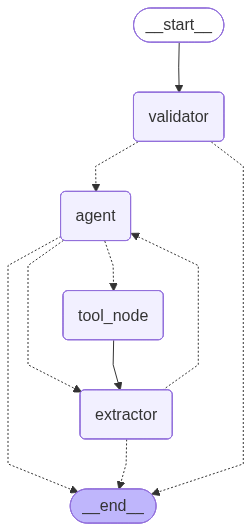

In [7]:
# --- Graph Wiring ---

workflow = StateGraph(RCAState)

workflow.add_node("validator", validator_node)
workflow.add_node("agent", agent_node)
workflow.add_node("tool_node", ToolNode(ALL_TOOLS))
workflow.add_node("extractor", extractor_node)

workflow.add_edge(START, "validator")
workflow.add_conditional_edges(
    "validator",
    route_after_validator,
    {"agent": "agent", END: END},
)
workflow.add_conditional_edges(
    "agent",
    route_after_agent,
    {"tool_node": "tool_node", "extractor": "extractor", END: END},
)
workflow.add_edge("tool_node", "extractor")
workflow.add_conditional_edges(
    "extractor",
    route_after_extractor,
    {"agent": "agent", END: END},
)

memory = MemorySaver()
memory.serde.allowed_extra_state_types = [Hypothesis, Evidence]

app = workflow.compile(checkpointer=memory)

print("Graph compiled successfully!")

from utils.utils import display_graph
display_graph(app)

In [8]:
# --- Interactive Driver ---

def display_hypotheses(hypotheses: List[Hypothesis]) -> None:
    if not hypotheses:
        print("  (No hypotheses yet)")
        return
    total = sum(h.confidence for h in hypotheses)
    for h in sorted(hypotheses, key=lambda x: x.confidence, reverse=True):
        bar = "█" * int(h.confidence * 10) + "░" * (10 - int(h.confidence * 10))
        if h.confidence <= 0.05:
            status = "✗ RULED OUT"
        elif h.confidence >= 0.50:
            status = "★ LIKELY"
        else:
            status = "○"
        print(f"\n  {h.id} [{bar}] {h.confidence:.0%}  {status}")
        print(f"  Root cause: {h.statement}")
        if h.evidence:
            print(f"  Evidence ({len(h.evidence)} source(s)):")
            for ev in h.evidence:
                icon = "+" if ev.direction == "supports" else "-"
                ref = ev.source_id
                if ev.section:
                    ref += f" § {ev.section}"
                print(f"    [{icon}] [{ev.source_type}] {ref}")
                if ev.snippet:
                    print(f"         snippet: \"{ev.snippet[:100]}\"")
                if ev.how_to_check:
                    print(f"         check:   {ev.how_to_check[:120]}")
                if ev.repair_action:
                    print(f"         fix:     {ev.repair_action[:120]}")
    print(f"\n  Σ = {total:.0%}  (should be 100%)")

def run_rca(thread_id: str | None = None) -> None:
    thread_id = thread_id or f"rca-{uuid.uuid4().hex[:6]}"
    config = {"configurable": {"thread_id": thread_id}}

    print("=" * 60)
    print("RCA COPILOT — type 'exit' to quit")
    print("Tip: ask 'action plan' to wrap up")
    print(f"Session: {thread_id}")
    print("=" * 60)

    while True:
        user_input = input("\nYou: ").strip()
        if not user_input or user_input.lower() in {"exit", "quit"}:
            break

        result = app.invoke(
            {"messages": [HumanMessage(content=user_input)]},
            config,
        )

        last_ai = next(
            (m for m in reversed(result["messages"])
             if isinstance(m, AIMessage) and m.content.strip()),
            None,
        )

        if last_ai:
            print(f"\nAgent: {last_ai.content}")

        print("\n── Hypothesis Ledger ──────────────────────────────")
        display_hypotheses(result.get("hypotheses", []))
        print("\n───────────────────────────────────────────────────")

run_rca()

RCA COPILOT — type 'exit' to quit
Tip: ask 'action plan' to wrap up
Session: rca-b88472
[Validator] Validated: machine=CB-200, symptom=belt misalignment, period=2025-01-10
[Agent] iteration=0, tool_calls=3
[Extractor] + H1: Idler Misalignment causing belt drift
[Extractor] + H2: Frame Skew causing belt drift
[Extractor] + H3: Air in hydraulic circuit causing cylinder synchronization error
[Extractor] + H4: Internal leakage causing cylinder synchronization error
[Extractor] + H5: Compressor leak causing low air bearing pressure
[Extractor] + H6: Air filter saturation causing low air bearing pressure
[Extractor] 6 updates → 6 hypotheses total
[Agent] iteration=1, tool_calls=0
[Extractor] 1 updates → 6 hypotheses total

Agent: I found several possible causes for the belt misalignment on the CB-200. Here's my current model:

- **H1 — Idler Misalignment** (17%) — [graph | KI-07]  
  Check: Perform visual inspection of idler alignment.  
  Repair: Adjust idler positioning as necessary.

- **

Deserializing unregistered type __main__.Hypothesis from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Hypothesis')]
Deserializing unregistered type __main__.Hypothesis from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Hypothesis')]
Deserializing unregistered type __main__.Hypothesis from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Hypothesis')]
Deserializing unregistered type __main__.Hypothesis from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Hypothesis')]
Deserializing unregistered type __main__.Hypothesis from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Hypothesis')]
Deserializing unregistered type __main__.Hypothesis from checkpoint. This will be blo

[Agent] iteration=2, tool_calls=0
[Extractor] 1 updates → 6 hypotheses total

Agent: OK, H1 ruled out — its probability redistributes to the remaining causes. Given that the idler was the problem, H2 (Frame Skew) is now my top suspect (20%). 

Here's the updated model:

- **H2 — Frame Skew** (20%) — [graph | KI-07]  
  Check: Inspect frame for skewness.  
  Repair: Correct geometric misalignment of the frame.

- **H3 — Take-up Pulley Misalignment** (20%) — [procedure | CB200-TSP-001 § 3.1]  
  Check: Stop the belt and check head and tail pulley alignment with a string line or laser.  
  Repair: Adjust take-up screw on the side toward which the belt is drifting.

- **H4 — Carry Roller Seized or Tilted** (20%) — [procedure | CB200-TSP-001 § 3.1]  
  Check: Inspect all carry rollers along the belt length for any seized or tilted rollers.  
  Repair: Replace seized rollers.

- **H5 — Belt Damage** (20%) — [procedure | CB200-TSP-001 § 3.1]  
  Check: Inspect the belt for cuts, tears, or une